In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, 
                             precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

In [6]:
# importing datasets
import opendatasets as od

In [7]:
dataset = "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"

In [8]:
od.download(dataset)

Skipping, found downloaded files in ".\creditcardfraud" (use force=True to force download)


In [9]:
import os

corrected_path = r".\creditcardfraud"

if os.path.exists(corrected_path):
    print(os.listdir(corrected_path))
else:
    print(f"Path {corrected_path} does not exist")

['creditcard.csv']


In [10]:
# Loading all data
data_dir = r".\creditcardfraud"

df = pd.read_csv(f"{data_dir}/creditcard.csv")

In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [32]:
pd.set_option('display.max_columns', None)

In [36]:
df[df['Class'] == 1]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Day,Log_Amount,Amount_Category
541,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,-0.016822,0.416956,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,1,0.112778,0,0.000000,Very Low
623,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1,0.131111,0,6.272877,High
4920,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,2.032912,-6.560124,0.022937,-1.470102,-0.698826,-2.282194,-4.781831,-2.615665,-1.334441,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1,1.239444,0,5.484506,Medium
6108,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,4.895844,-10.912819,0.184372,-6.771097,-0.007326,-7.358083,-12.598419,-5.131549,0.308334,-0.171608,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,1,1.940556,0,4.094345,Low
6329,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,2.101344,-4.609628,1.464378,-6.079337,-0.339237,2.581851,6.739384,3.042493,-2.721853,0.009061,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1,2.088611,0,0.693147,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,-5.587794,2.115795,-5.417424,-1.235123,-6.665177,0.401701,-2.897825,-4.570529,-1.315147,0.391167,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,1,22.983889,1,5.968708,Medium
280143,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,-3.232153,2.858466,-3.096915,-0.792532,-5.210141,-0.613803,-2.155297,-3.267116,-0.688505,0.737657,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,1,23.040833,1,0.565314,Very Low
280149,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,-3.463891,1.794969,-2.775022,-0.418950,-4.057162,-0.712616,-1.603015,-5.035326,-0.507000,0.266272,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,1,23.041944,1,4.368054,Low
281144,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,-5.245984,1.933520,-5.030465,-1.127455,-6.416628,0.141237,-2.549498,-4.614717,-1.478138,-0.035480,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,1,23.212778,1,5.505332,Medium


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   V1               284807 non-null  float64 
 1   V2               284807 non-null  float64 
 2   V3               284807 non-null  float64 
 3   V4               284807 non-null  float64 
 4   V5               284807 non-null  float64 
 5   V6               284807 non-null  float64 
 6   V7               284807 non-null  float64 
 7   V8               284807 non-null  float64 
 8   V9               284807 non-null  float64 
 9   V10              284807 non-null  float64 
 10  V11              284807 non-null  float64 
 11  V12              284807 non-null  float64 
 12  V13              284807 non-null  float64 
 13  V14              284807 non-null  float64 
 14  V15              284807 non-null  float64 
 15  V16              284807 non-null  float64 
 16  V17              284

In [38]:
df.shape

(284807, 33)

In [39]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [15]:
# Create time-based features (seconds to hour of day)
df['Hour'] = (df['Time'] / 3600) % 24
df['Day'] = (df['Time'] / (3600*24)).astype(int)


df['Log_Amount'] = np.log1p(df['Amount'])


df['Amount_Category'] = pd.cut(df['Amount'], 
                                 bins=[-1, 50, 100, 500, 5000, float('inf')],
                                 labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])


df = df.drop(['Time', 'Amount'], axis=1)

print("New features created: Hour, Day, Log_Amount, Amount_Category")


New features created: Hour, Day, Log_Amount, Amount_Category


In [16]:
X = df.drop('Class', axis=1)
y = df['Class']


numeric_features = [col for col in X.columns if col != 'Amount_Category']
categorical_features = ['Amount_Category']


X = pd.get_dummies(X, columns=categorical_features, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"Features after encoding: {X_train_scaled.shape[1]}")


Training set: 199364 samples
Test set: 85443 samples
Features after encoding: 35


In [17]:
# SMOTE creates synthetic fraud samples
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # 50% fraud, 100% legit
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nBalanced training distribution:\n{pd.Series(y_train_balanced).value_counts()}")

Original training distribution:
Class
0    199020
1       344
Name: count, dtype: int64

Balanced training distribution:
Class
0    199020
1     99510
Name: count, dtype: int64


In [18]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced')
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"  Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"  Precision: {results[name]['Precision']:.4f}")
    print(f"  Recall:    {results[name]['Recall']:.4f}")
    print(f"  F1-Score:  {results[name]['F1-Score']:.4f}")
    print(f"  ROC-AUC:   {results[name]['ROC-AUC']:.4f}")


Training Logistic Regression...
  Accuracy:  0.9762
  Precision: 0.0605
  Recall:    0.8784
  F1-Score:  0.1133
  ROC-AUC:   0.9696

Training Random Forest...
  Accuracy:  0.9994
  Precision: 0.8788
  Recall:    0.7838
  F1-Score:  0.8286
  ROC-AUC:   0.9716

Training Gradient Boosting...
  Accuracy:  0.9979
  Precision: 0.4249
  Recall:    0.6689
  F1-Score:  0.5197
  ROC-AUC:   0.8337


In [19]:
best_model = models['Random Forest']
print("Random Forest selected as the best model based on performance metrics")
print(f"Random Forest Performance:")
print(f"  F1-Score:  {results['Random Forest']['F1-Score']:.4f}")
print(f"  ROC-AUC:   {results['Random Forest']['ROC-AUC']:.4f}")
print(f"  Recall:    {results['Random Forest']['Recall']:.4f}")

# Final evaluation with best model
y_pred_final = best_model.predict(X_test_scaled)
y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nFinal Random Forest Performance on Test Set:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_final):.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Legit', 'Fraud']))

Random Forest selected as the best model based on performance metrics
Random Forest Performance:
  F1-Score:  0.8286
  ROC-AUC:   0.9716
  Recall:    0.7838

Final Random Forest Performance on Test Set:
  Accuracy:  0.9994
  Precision: 0.8788
  Recall:    0.7838
  F1-Score:  0.8286
  ROC-AUC:   0.9716

Detailed Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.88      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443



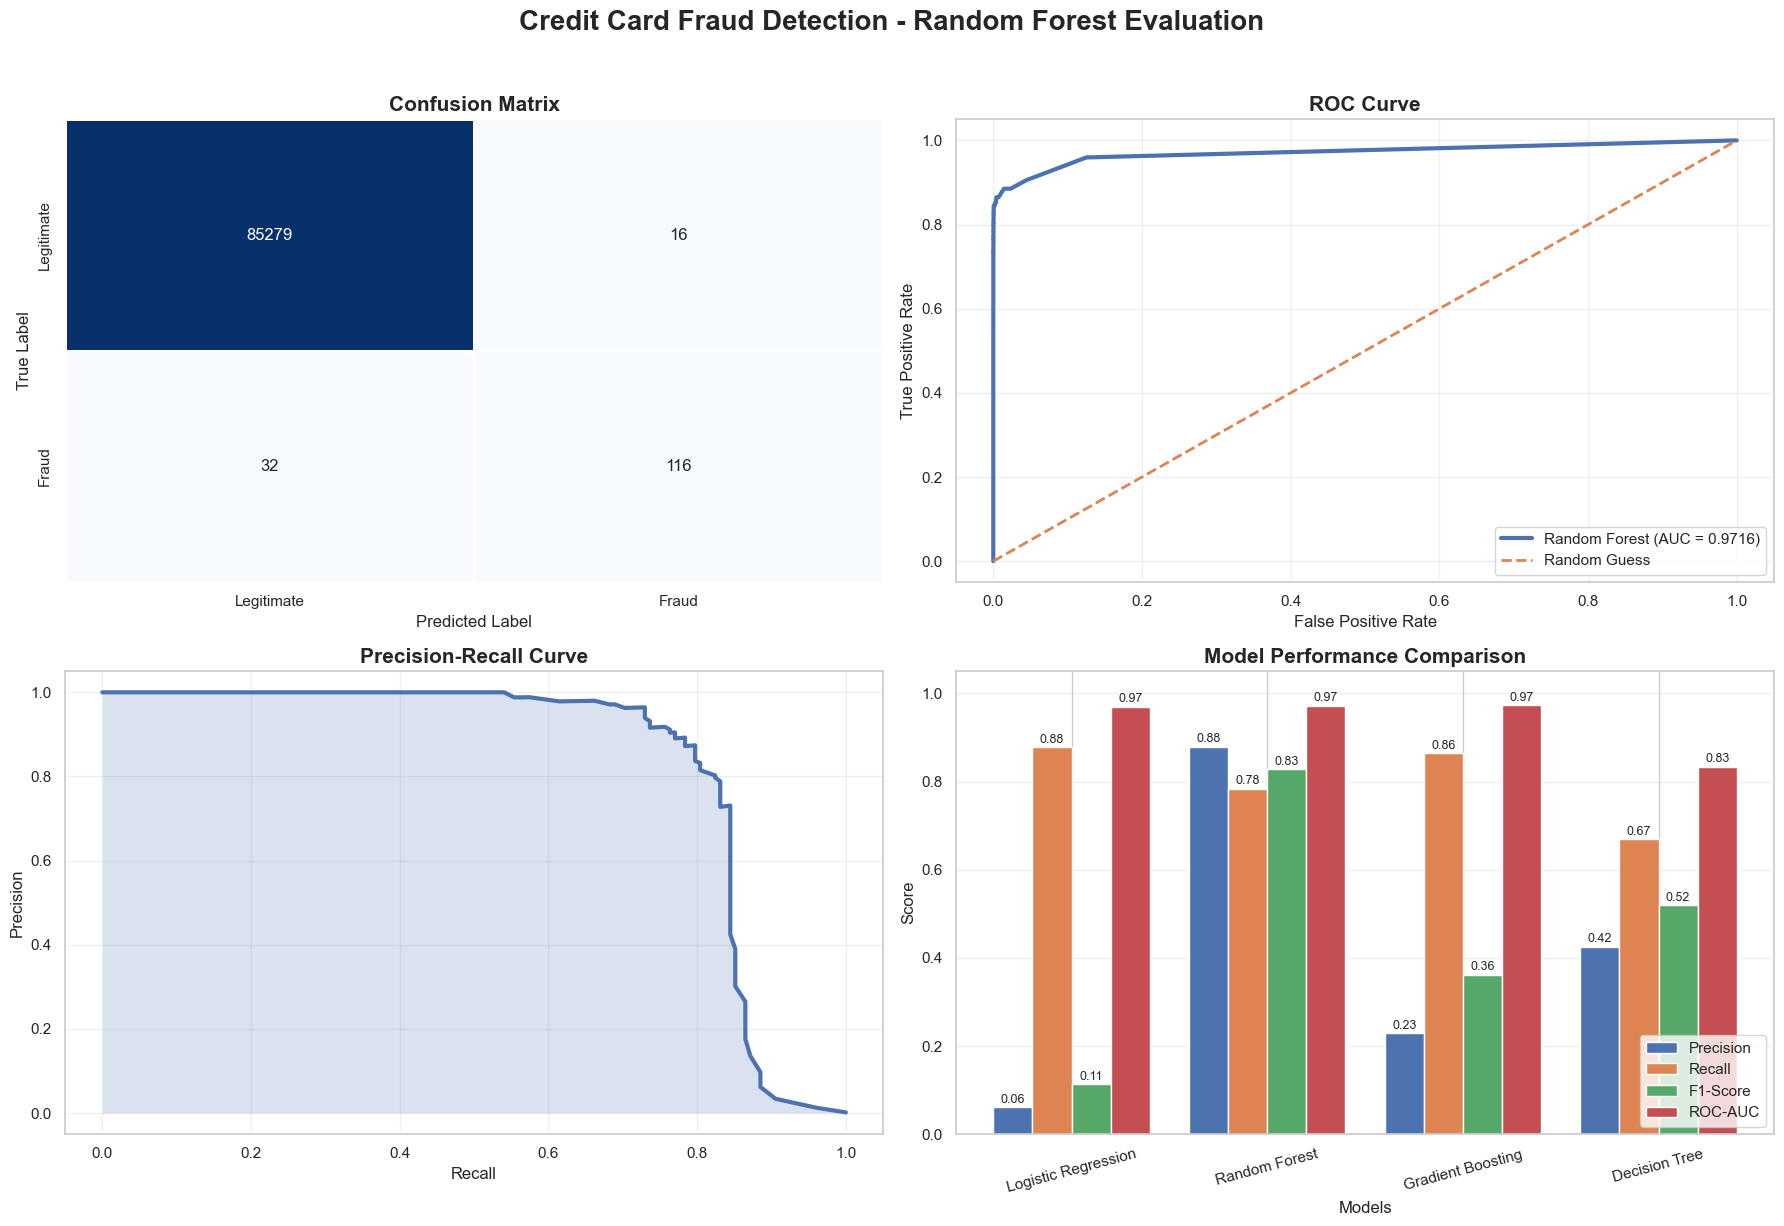

In [ ]:
# FRAUD DETECTION MODEL VISUALIZATION DASHBOARD

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

plt.style.use('default')
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Credit Card Fraud Detection - Random Forest Evaluation', fontsize=20, fontweight='bold', y=1.02)


# 1. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    linewidths=1, linecolor='white',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud'],
    ax=axes[0, 0]
)

axes[0, 0].set_title('Confusion Matrix', fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label', fontsize=12)
axes[0, 0].set_ylabel('True Label', fontsize=12)

# 2. ROC CURVE

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
auc = results['Random Forest']['ROC-AUC']

axes[0, 1].plot(fpr, tpr, linewidth=3, label=f'Random Forest (AUC = {auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', linewidth=2, label='Random Guess')

axes[0, 1].set_title('ROC Curve', fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# 3. PRECISION-RECALL CURVE

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_final)

axes[1, 0].plot(recall, precision, linewidth=3)
axes[1, 0].fill_between(recall, precision, alpha=0.2)

axes[1, 0].set_title('Precision-Recall Curve', fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].grid(alpha=0.3)


# 4. MODEL PERFORMANCE COMPARISON


model_names = list(results.keys())
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(model_names))
width = 0.2

for i, metric in enumerate(metrics):
    metric_values = [results[model][metric] for model in model_names]

    bars = axes[1, 1].bar(x + i * width, metric_values, width, label=metric)

    for bar in bars:
        height = bar.get_height()

        axes[1, 1].text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            fontsize=9
        )

axes[1, 1].set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
axes[1, 1].set_xlabel('Models', fontsize=12)
axes[1, 1].set_ylabel('Score', fontsize=12)

axes[1, 1].set_xticks(x + width * 1.5)
axes[1, 1].set_xticklabels(model_names, rotation=15)

axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend(loc='lower right', frameon=True)
axes[1, 1].grid(alpha=0.3, axis='y')

# FINAL LAYOUT
plt.tight_layout()
plt.show()

In [ ]:
# Find optimal threshold to balance precision and recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_final)

# Calculate F1 score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])  # -1 because last threshold is 1.0
optimal_threshold = thresholds[optimal_idx] if len(thresholds) > 0 else 0.5

print(f"Optimal threshold based on F1-score: {optimal_threshold:.4f}")
print(f"F1-score at optimal threshold: {f1_scores[optimal_idx]:.4f}")

# Apply optimal threshold
y_pred_optimal = (y_pred_proba_final >= optimal_threshold).astype(int)

print(f"\nPerformance with Optimal Threshold ({optimal_threshold:.4f}):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_optimal):.4f}")

Optimal threshold based on F1-score: 0.5300
F1-score at optimal threshold: 0.8345

Performance with Optimal Threshold (0.5300):
  Accuracy:  0.9995
  Precision: 0.8923
  Recall:    0.7838
  F1-Score:  0.8345


In [43]:
import joblib

# Save the best model and preprocessors
joblib.dump(best_model, 'fraud_model_v2.pkl', protocol=4)
joblib.dump(scaler, 'scaler_v2.pkl', protocol=4)
joblib.dump(X.columns.tolist(), 'features_v2.pkl', protocol=4)
joblib.dump(optimal_threshold, 'threshold_v2.pkl', protocol=4)

print("✅ New model files created")

print("✅ Models re-saved with protocol=4")

print("Random Forest model and preprocessors saved successfully!")
print("  - random_forest_fraud_model.pkl")
print("  - scaler.pkl")
print("  - feature_columns.pkl")
print("  - optimal_threshold.pkl")

✅ New model files created
✅ Models re-saved with protocol=4
Random Forest model and preprocessors saved successfully!
  - random_forest_fraud_model.pkl
  - scaler.pkl
  - feature_columns.pkl
  - optimal_threshold.pkl


In [44]:
import joblib
test = joblib.load("fraud_model_v2.pkl")
print("✅ Model loads locally")

✅ Model loads locally


In [1]:
def predict_fraud_with_rf(transaction_data, model, scaler, feature_columns, threshold=0.5):
    """
    Predict if a transaction is fraudulent using Random Forest.
    
    Parameters:
    - transaction_data: dict or DataFrame with transaction features
    - model: trained Random Forest model
    - scaler: fitted RobustScaler
    - feature_columns: list of feature names used in training
    - threshold: probability threshold for fraud classification
    
    Returns:
    - prediction: 0 (legit) or 1 (fraud)
    - probability: fraud probability
    - confidence: prediction confidence level
    """
    # Convert to DataFrame if dict
    if isinstance(transaction_data, dict):
        transaction_df = pd.DataFrame([transaction_data])
    else:
        transaction_df = transaction_data.copy()
    
    # Add engineered features
    if 'Time' in transaction_df.columns:
        transaction_df['Hour'] = (transaction_df['Time'] / 3600) % 24
        transaction_df['Day'] = (transaction_df['Time'] / (3600*24)).astype(int)
        transaction_df = transaction_df.drop('Time', axis=1)
    
    if 'Amount' in transaction_df.columns:
        transaction_df['Log_Amount'] = np.log1p(transaction_df['Amount'])
        transaction_df = transaction_df.drop('Amount', axis=1)
    
    # Handle Amount Category
    if 'Amount_Category' not in transaction_df.columns and 'Log_Amount' in transaction_df.columns:
        transaction_df['Amount_Category'] = pd.cut(
            transaction_df['Log_Amount'], 
            bins=[-1, 3.9, 4.6, 5.3, 6.2, float('inf')],
            labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
        )
    
    # One-hot encode categorical features
    if 'Amount_Category' in transaction_df.columns:
        transaction_df = pd.get_dummies(transaction_df, columns=['Amount_Category'], drop_first=True)
    
    # Align columns with training data
    for col in feature_columns:
        if col not in transaction_df.columns:
            transaction_df[col] = 0
    
    transaction_df = transaction_df[feature_columns]
    
    # Scale features
    transaction_scaled = scaler.transform(transaction_df)
    
    # Predict
    probability = model.predict_proba(transaction_scaled)[0][1]
    prediction = 1 if probability >= threshold else 0
    
    # Calculate confidence
    confidence = probability if prediction == 1 else 1 - probability
    
    return prediction, probability, confidence
